# ADA Project 2 — House Price Prediction 

## Setup — Import Libraries

In [61]:
# Basic libraries
import os
import warnings
from pathlib import Path

# Limit the number of threads to avoid possible performance issues
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and pipelines
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer

# Model selection and evaluation
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature selection and dimensionality reduction
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

# Regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# Boosting models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Keep notebook output clean
warnings.filterwarnings("ignore")

# Main settings
RANDOM_STATE = 42
CV_FOLDS = 5
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


## Setup — Load Train, Test, and Sample Submission Files

In [62]:
# File paths
TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")
SAMPLE_PATH = Path("sample_submission.csv")

# Kaggle dataset path
KAGGLE_DIR = Path("/kaggle/input/datasets/ammourmenad/ada-project-dataset")

# Local backup path
LOCAL_DIR = Path("/mnt/data")

# Use Kaggle paths if the files are not found beside the notebook
if not TRAIN_PATH.exists():
    TRAIN_PATH = KAGGLE_DIR / "train.csv"
if not TEST_PATH.exists():
    TEST_PATH = KAGGLE_DIR / "test.csv"
if not SAMPLE_PATH.exists():
    SAMPLE_PATH = KAGGLE_DIR / "sample_submission.csv"

# Use local paths as a final fallback
if not TRAIN_PATH.exists():
    TRAIN_PATH = LOCAL_DIR / "train.csv"
if not TEST_PATH.exists():
    TEST_PATH = LOCAL_DIR / "test.csv"
if not SAMPLE_PATH.exists():
    SAMPLE_PATH = LOCAL_DIR / "sample_submission.csv"

# Load the data
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

# Basic overview
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)
print("Sample submission columns:", sample_submission.columns.tolist())

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (2344, 82)
Test shape: (586, 81)
Sample submission shape: (586, 2)
Sample submission columns: ['PID', 'SalePrice']


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,382,527359050,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2009,WD,Family,152000
1,835,906475070,60,RL,NaN,28698,Pave,NaN,IR2,Low,...,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml,185000
2,1899,534429030,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,101800
3,679,535451170,90,RL,60.0,7200,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,90000
4,701,902109130,190,RM,63.0,7627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,94550


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,...,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal
1,2368,527450460,160,RM,21.0,1890,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal
2,2823,908128100,60,RL,62.0,7162,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal
3,2127,907135180,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
4,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,...,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal


,PID,SalePrice
0,903427090,160000.0
1,527450460,160000.0
2,908128100,160000.0
3,907135180,160000.0
4,910200080,160000.0


In [63]:
# Detect the ID column used in the submission file
submission_id_col = sample_submission.columns[0]

print("Submission ID column:", submission_id_col)

# Check whether the same ID column exists in the test set
if submission_id_col in test.columns:
    ids_match = sample_submission[submission_id_col].equals(test[submission_id_col])
    print("Submission IDs match test IDs:", ids_match)
else:
    print("ID column not found in test.csv. The sample submission order will be used.")

Submission ID column: PID
Submission IDs match test IDs: True


# PART 1 — Exploratory Data Analysis (EDA)

In [64]:
# Check the size of the datasets and the target column
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("SalePrice in train:", "SalePrice" in train.columns)
print("SalePrice in test:", "SalePrice" in test.columns)

# Separate columns by data type
numeric_cols_raw = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols_raw))
print("Number of categorical columns:", len(categorical_cols_raw))

print("Categorical columns:")
print(categorical_cols_raw)

Train shape: (2344, 82)
Test shape: (586, 81)
SalePrice in train: True
SalePrice in test: False
Number of numeric columns: 39
Number of categorical columns: 43
Categorical columns:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


In [65]:
# Count missing values in each dataset
missing_train = train.isna().sum().sort_values(ascending=False)
missing_test = test.isna().sum().sort_values(ascending=False)

# Combine missing value counts and percentages in one table
missing_summary = pd.DataFrame({
    "Train Missing": missing_train,
    "Train Missing %": (missing_train / len(train) * 100).round(2),
    "Test Missing": missing_test,
    "Test Missing %": (missing_test / len(test) * 100).round(2)
}).fillna(0)

# Keep only columns that have at least one missing value
missing_summary = missing_summary[
    (missing_summary["Train Missing"] > 0) |
    (missing_summary["Test Missing"] > 0)
]

print("Columns with missing values:", missing_summary.shape[0])
display(missing_summary.head(30))

# Check for duplicated rows
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Columns with missing values: 27


,Train Missing,Train Missing %,Test Missing,Test Missing %
Alley,2182,93.09,550.0,93.86
Bsmt Cond,61,2.60,19.0,3.24
Bsmt Exposure,63,2.69,20.0,3.41
Bsmt Full Bath,1,0.04,1.0,0.17
Bsmt Half Bath,1,0.04,1.0,0.17
Bsmt Qual,61,2.60,19.0,3.24
Bsmt Unf SF,1,0.04,0.0,0.00
BsmtFin SF 1,1,0.04,0.0,0.00
BsmtFin SF 2,1,0.04,0.0,0.00
BsmtFin Type 1,61,2.60,19.0,3.24


Duplicate rows in train: 0
Duplicate rows in test: 0


In [66]:
# Summary statistics and skewness for numeric columns
summary_numeric = train.describe().T
summary_numeric["skewness"] = train.select_dtypes(include=[np.number]).skew()

# Show the most skewed numeric features
display(summary_numeric.sort_values("skewness", ascending=False).head(25))

,count,mean,std,min,25%,50%,75%,max,skewness
Misc Val,2344.0,58.055034,623.375121,0.0,0.00,0.0,0.00,17000.0,20.416138
Pool Area,2344.0,2.582765,38.324145,0.0,0.00,0.0,0.00,800.0,15.898588
Lot Area,2344.0,10127.857509,8050.908132,1300.0,7466.50,9356.5,11484.25,215245.0,13.743796
Low Qual Fin SF,2344.0,4.357082,44.323993,0.0,0.00,0.0,0.00,1064.0,12.959105
3Ssn Porch,2344.0,2.422782,24.524362,0.0,0.00,0.0,0.00,508.0,12.140302
Kitchen AbvGr,2344.0,1.043089,0.211339,0.0,1.00,1.0,1.00,3.0,4.493078
BsmtFin SF 2,2343.0,50.097311,170.396999,0.0,0.00,0.0,0.00,1526.0,4.185302
Bsmt Half Bath,2343.0,0.059326,0.241644,0.0,0.00,0.0,0.00,2.0,4.003080
Enclosed Porch,2344.0,24.731655,67.030943,0.0,0.00,0.0,0.00,1012.0,3.993799
Screen Porch,2344.0,16.010239,55.820882,0.0,0.00,0.0,0.00,576.0,3.894896


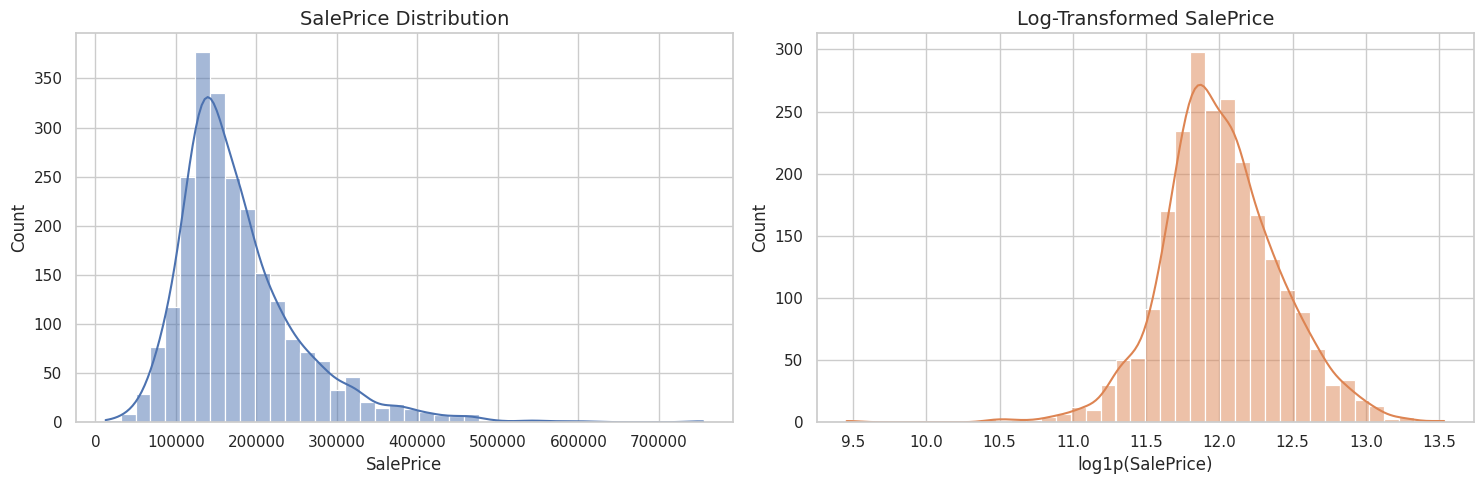

Raw SalePrice skewness: 1.7505967618875342
Log-transformed SalePrice skewness: -0.09069864066048615


In [67]:
# Compare the target distribution before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original target distribution
sns.histplot(train["SalePrice"], kde=True, bins=40, ax=axes[0], color="C0")
axes[0].set_title("SalePrice Distribution")
axes[0].set_xlabel("SalePrice")

# Log-transformed target distribution
sns.histplot(np.log1p(train["SalePrice"]), kde=True, bins=40, ax=axes[1], color="C1")
axes[1].set_title("Log-Transformed SalePrice")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()

print("Raw SalePrice skewness:", train["SalePrice"].skew())
print("Log-transformed SalePrice skewness:", np.log1p(train["SalePrice"]).skew())

In [68]:
# Correlation between numeric features and the target
corr_with_target = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print("Top positive correlations with SalePrice:")
display(corr_with_target.head(20).to_frame("Correlation with SalePrice"))

print("\nTop negative correlations with SalePrice:")
display(corr_with_target.tail(10).to_frame("Correlation with SalePrice"))

Top positive correlations with SalePrice:


,Correlation with SalePrice
SalePrice,1.000000
Overall Qual,0.795298
Gr Liv Area,0.698315
Garage Cars,0.644304
Garage Area,0.633106
Total Bsmt SF,0.612256
1st Flr SF,0.607433
Year Built,0.545409
Full Bath,0.542053
Year Remod/Add,0.517653



Top negative correlations with SalePrice:


,Correlation with SalePrice
Low Qual Fin SF,-0.016025
Misc Val,-0.017729
Order,-0.020621
Bsmt Half Bath,-0.023675
Yr Sold,-0.037686
MS SubClass,-0.066351
Overall Cond,-0.104085
Kitchen AbvGr,-0.115860
Enclosed Porch,-0.130722
PID,-0.233448


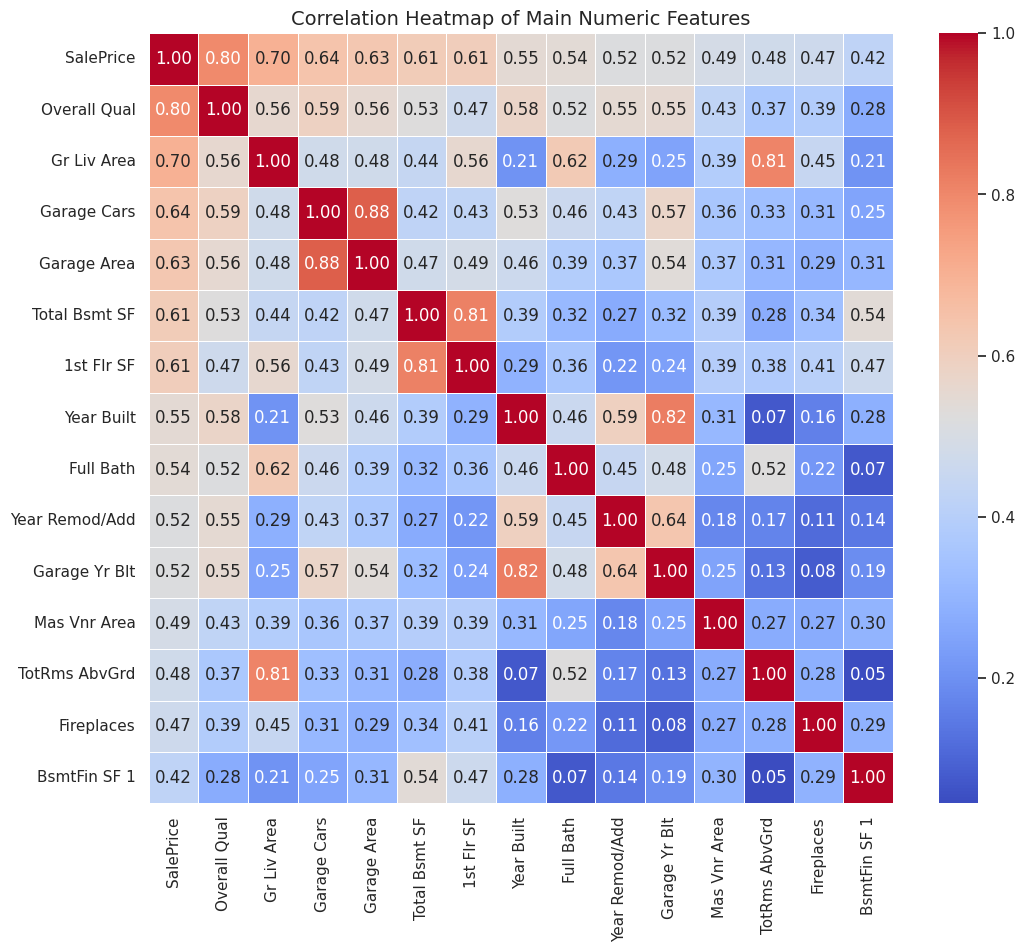

In [69]:
# Select the numeric features most correlated with SalePrice
important_corr_features = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()

# Plot their correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    train[important_corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Main Numeric Features")
plt.show()

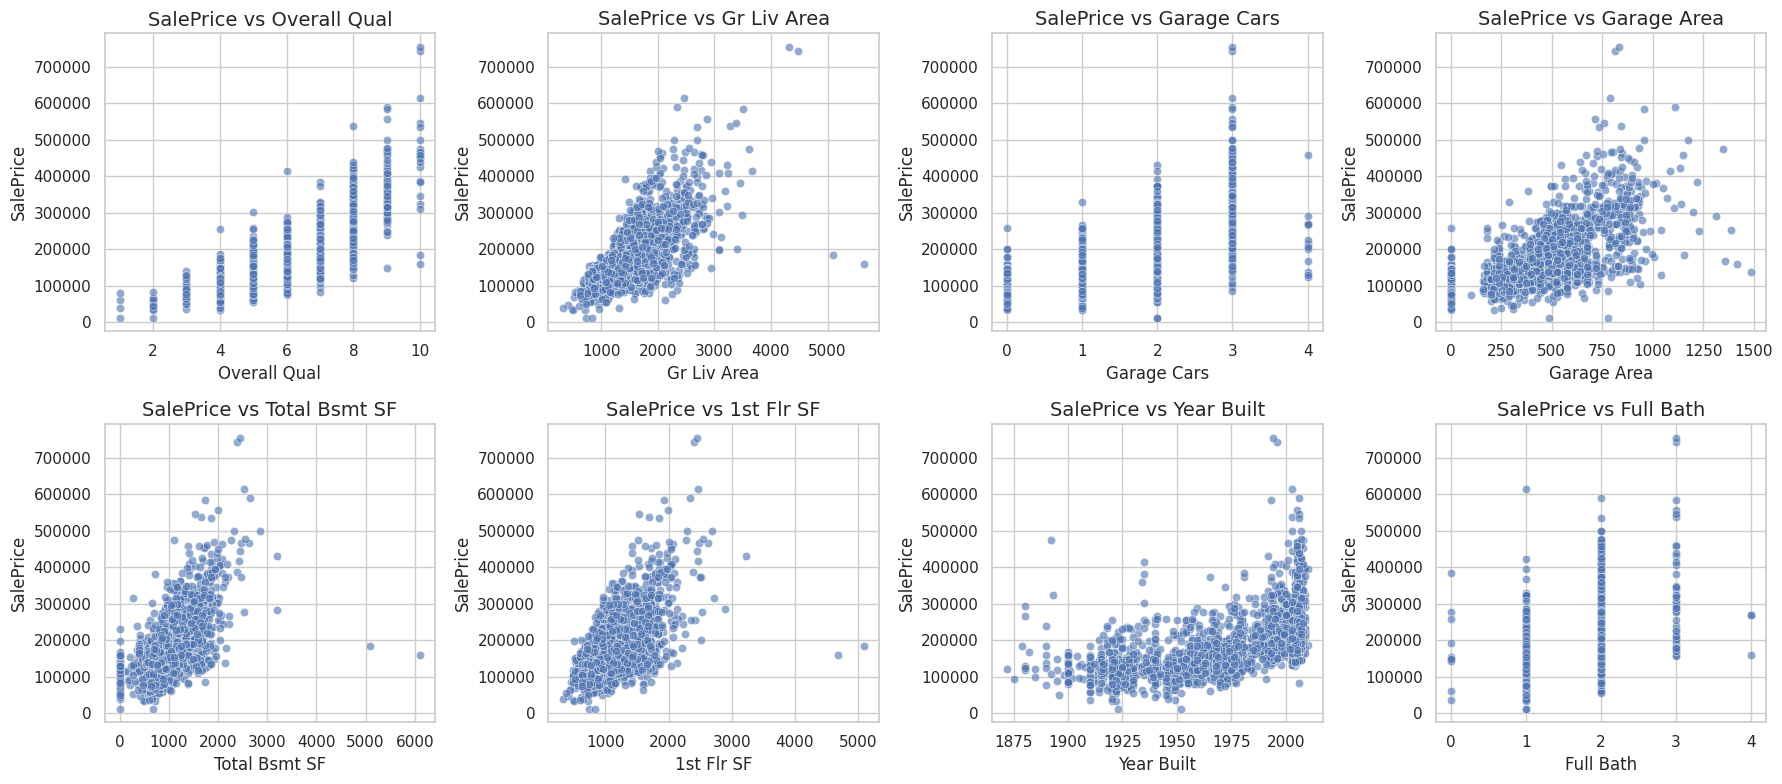

In [70]:
# Scatterplots for some important numeric features
selected_numeric_features = [
    "Overall Qual", "Gr Liv Area", "Garage Cars", "Garage Area",
    "Total Bsmt SF", "1st Flr SF", "Year Built", "Full Bath"
]

# Keep only columns that are actually present in the dataset
selected_numeric_features = [
    col for col in selected_numeric_features 
    if col in train.columns
]

# Create the subplot grid
n_cols = 4
n_rows = int(np.ceil(len(selected_numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).flatten()

# Plot SalePrice against each selected feature
for ax, col in zip(axes, selected_numeric_features):
    sns.scatterplot(data=train, x=col, y="SalePrice", alpha=0.6, ax=ax)
    ax.set_title(f"SalePrice vs {col}")

# Hide empty plots if the grid has extra spaces
for ax in axes[len(selected_numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

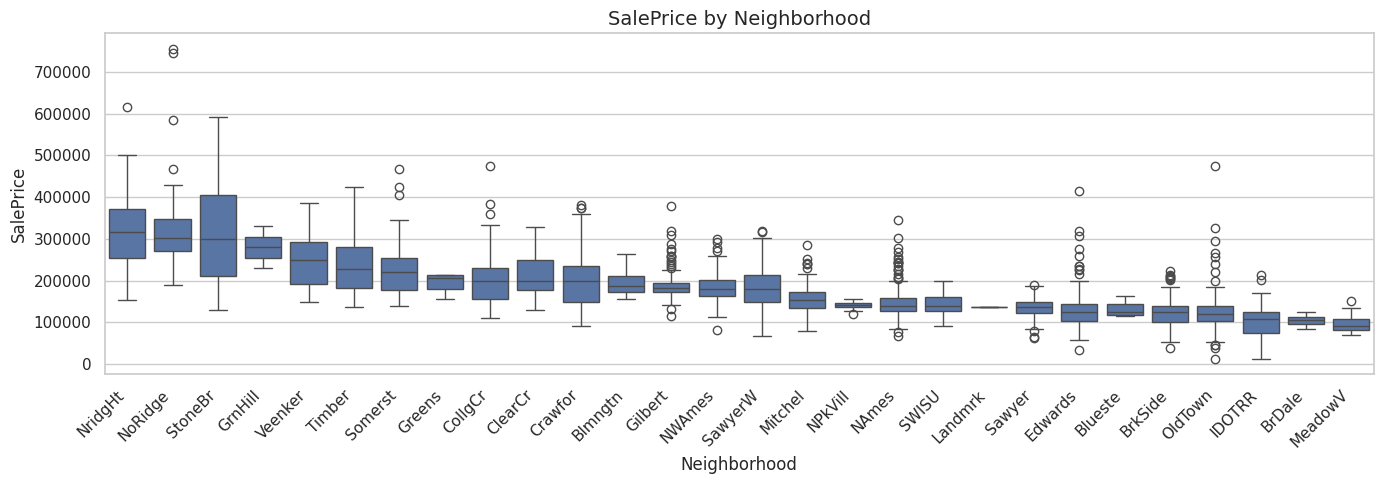

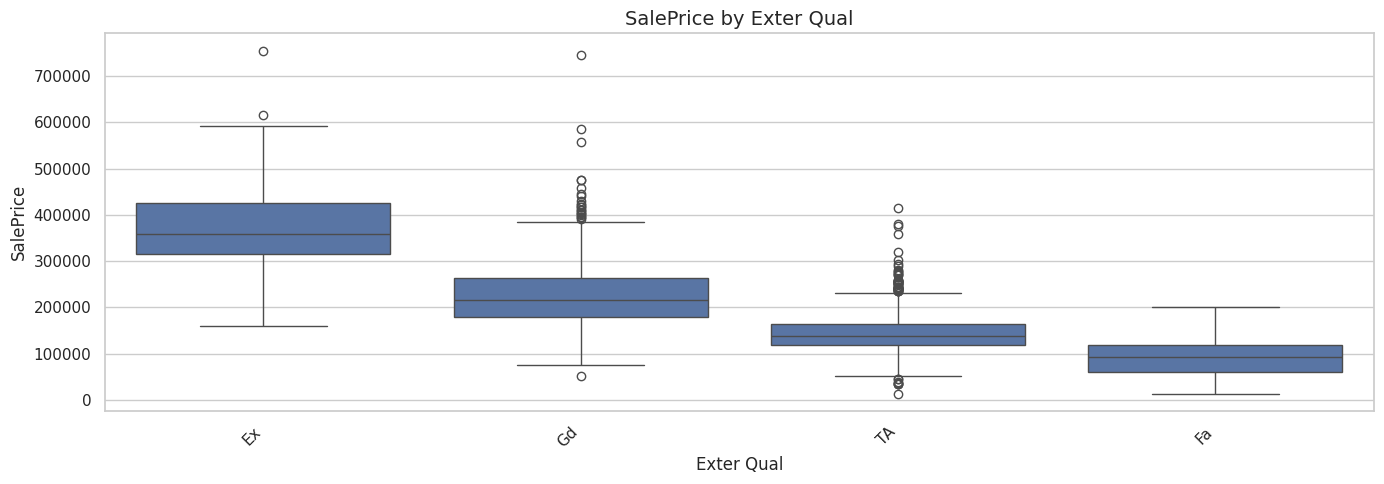

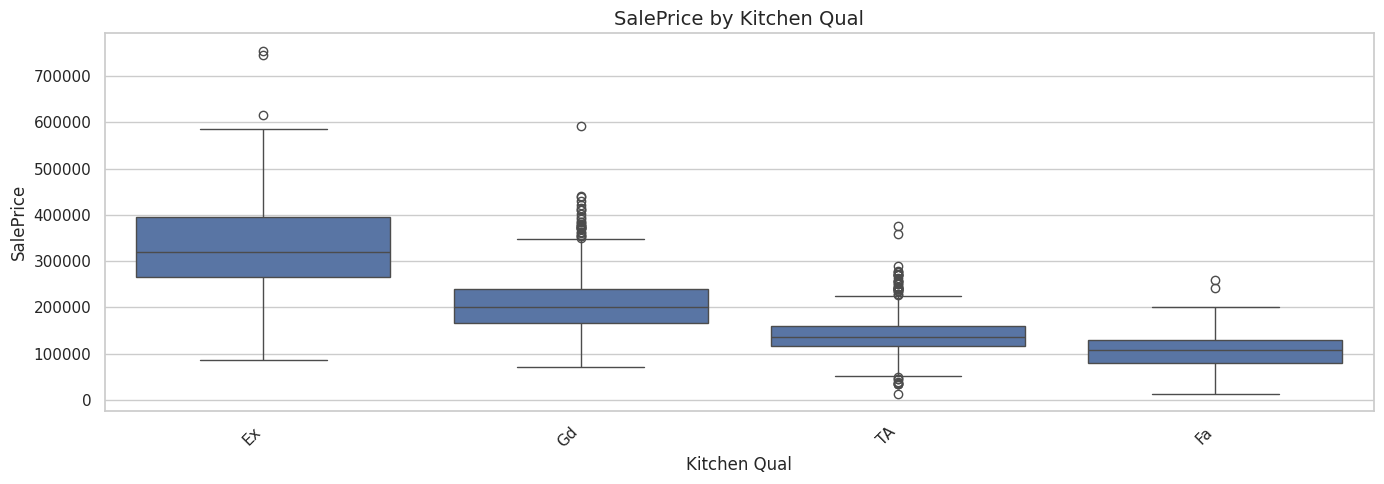

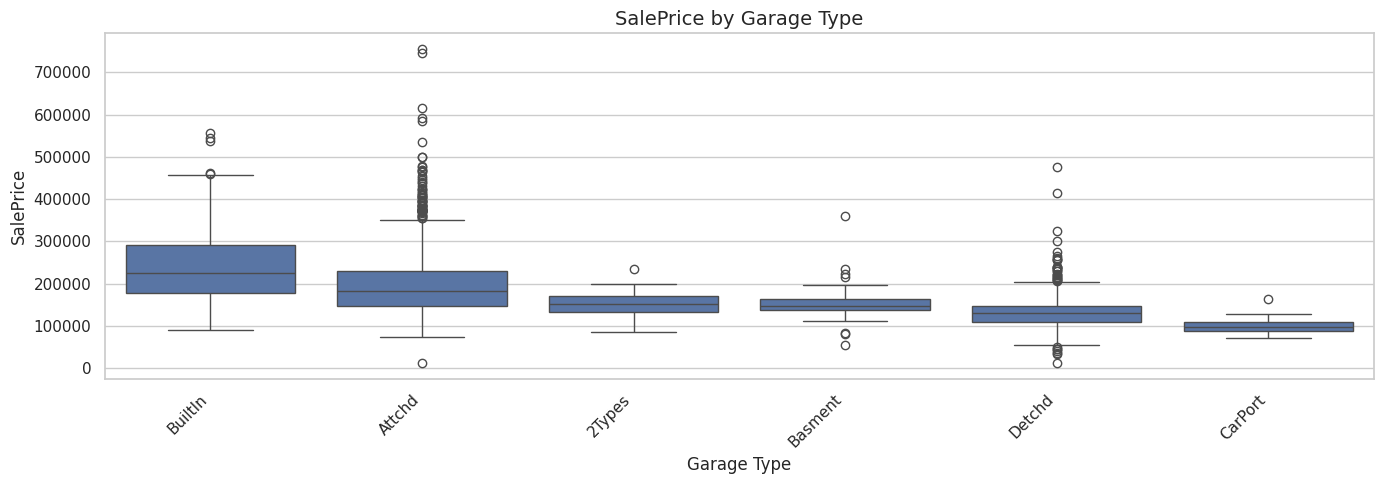

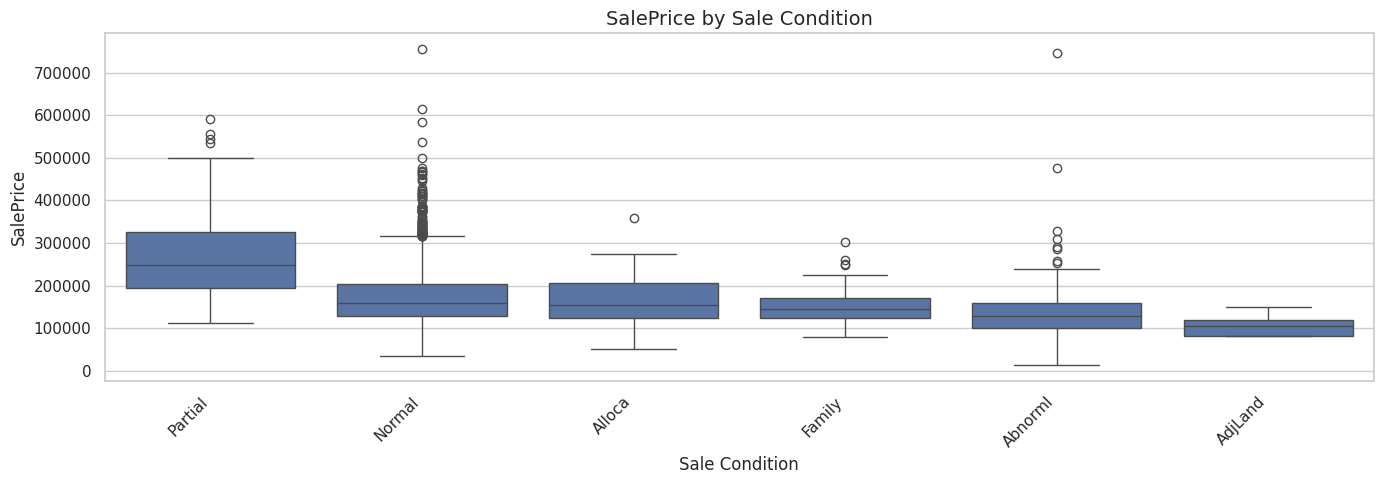

In [71]:
# Boxplots for selected categorical features
categorical_features_to_plot = [
    "Neighborhood",
    "Exter Qual",
    "Kitchen Qual",
    "Garage Type",
    "Sale Condition"
]

for col in categorical_features_to_plot:
    if col in train.columns:
        # Order categories by median SalePrice
        order = train.groupby(col)["SalePrice"].median().sort_values(ascending=False).index

        plt.figure(figsize=(14, 5))
        sns.boxplot(data=train, x=col, y="SalePrice", order=order)

        plt.title(f"SalePrice by {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

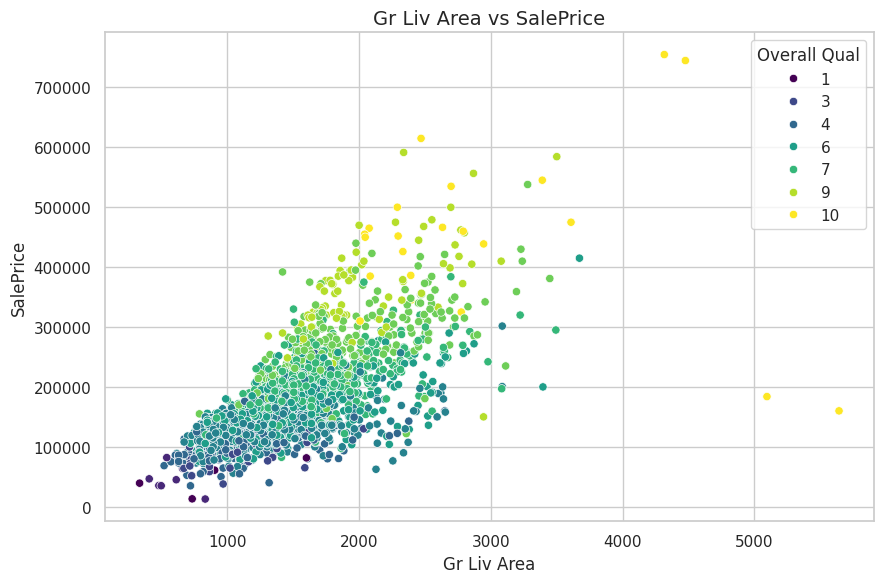

Potential Gr Liv Area outliers: 2


,Order,PID,Gr Liv Area,Overall Qual,SalePrice
391,1499,908154235,5642,10,160000
1634,2181,908154195,5095,10,183850


In [72]:
# Check possible outliers in Gr Liv Area
if "Gr Liv Area" in train.columns:
    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=train,
        x="Gr Liv Area",
        y="SalePrice",
        hue="Overall Qual" if "Overall Qual" in train.columns else None,
        palette="viridis"
    )

    plt.title("Gr Liv Area vs SalePrice")
    plt.tight_layout()
    plt.show()

    # Very large houses with relatively low prices may be unusual points
    possible_outliers = train[
        (train["Gr Liv Area"] > 4500) &
        (train["SalePrice"] < 300000)
    ]

    print("Potential Gr Liv Area outliers:", possible_outliers.shape[0])

    # Display only useful columns if they exist
    outlier_cols = [
        col for col in ["Order", "PID", "Gr Liv Area", "Overall Qual", "SalePrice"]
        if col in possible_outliers.columns
    ]

    display(possible_outliers[outlier_cols])

# PART 2 — Basic Preprocessing and Feature Engineering

In [73]:
# In these categorical columns, missing values usually mean "None" or "not available"
NONE_CATEGORICAL_COLS = [
    "Alley", "Mas Vnr Type", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Fireplace Qu", "Garage Type",
    "Garage Finish", "Garage Qual", "Garage Cond", "Pool QC", "Fence", "Misc Feature"
]

# In these numeric columns, missing values usually mean the feature does not exist
ZERO_NUMERIC_COLS = [
    "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF",
    "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars", "Garage Area", "Garage Yr Blt"
]

# Columns that should not be used as model features
ID_COLS = [col for col in ["Order", "PID"] if col in train.columns]
TARGET_COL = "SalePrice"

print("ID columns removed from modeling:", ID_COLS)

ID columns removed from modeling: ['Order', 'PID']


In [74]:
def add_house_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add useful house-related features for quick analysis."""
    df = df.copy()

    # Missing categorical values that usually mean the feature does not exist
    for col in NONE_CATEGORICAL_COLS:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    # Missing numeric values that usually mean zero
    for col in ZERO_NUMERIC_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Limit very large living area values in the basic version
    if "Gr Liv Area" in df.columns:
        df["Gr Liv Area"] = df["Gr Liv Area"].clip(upper=4000)

    # Size-related features
    if {"Total Bsmt SF", "1st Flr SF", "2nd Flr SF"}.issubset(df.columns):
        df["TotalSF"] = (
            df["Total Bsmt SF"] +
            df["1st Flr SF"] +
            df["2nd Flr SF"]
        ).clip(upper=6000)

    if {"1st Flr SF", "2nd Flr SF"}.issubset(df.columns):
        df["TotalAboveGroundSF"] = df["1st Flr SF"] + df["2nd Flr SF"]

    if {"Gr Liv Area", "Total Bsmt SF"}.issubset(df.columns):
        df["TotalLivingAreaWithBasement"] = (
            df["Gr Liv Area"] +
            df["Total Bsmt SF"]
        ).clip(upper=7000)

    # Bathroom-related feature
    bath_cols = ["Full Bath", "Half Bath", "Bsmt Full Bath", "Bsmt Half Bath"]
    if all(col in df.columns for col in bath_cols):
        df["TotalBathrooms"] = (
            df["Full Bath"] +
            0.5 * df["Half Bath"] +
            df["Bsmt Full Bath"] +
            0.5 * df["Bsmt Half Bath"]
        )

    # Age-related features
    if {"Yr Sold", "Year Built"}.issubset(df.columns):
        df["HouseAge"] = df["Yr Sold"] - df["Year Built"]
        df["IsNewHouse"] = (df["HouseAge"] <= 1).astype(int)

    if {"Yr Sold", "Year Remod/Add"}.issubset(df.columns):
        df["RemodAge"] = df["Yr Sold"] - df["Year Remod/Add"]

        if "Year Built" in df.columns:
            df["WasRemodeled"] = (df["Year Remod/Add"] != df["Year Built"]).astype(int)
        else:
            df["WasRemodeled"] = 0

    if {"Yr Sold", "Garage Yr Blt"}.issubset(df.columns):
        df["GarageAge"] = df["Yr Sold"] - df["Garage Yr Blt"]
        df.loc[df["Garage Yr Blt"] == 0, "GarageAge"] = 0

    # Porch and outdoor space
    porch_cols = ["Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch", "Wood Deck SF"]
    existing_porch_cols = [col for col in porch_cols if col in df.columns]

    if existing_porch_cols:
        df["TotalPorchSF"] = df[existing_porch_cols].sum(axis=1)

    # Simple yes/no indicators
    if "Garage Area" in df.columns:
        df["HasGarage"] = (df["Garage Area"] > 0).astype(int)
    if "Total Bsmt SF" in df.columns:
        df["HasBasement"] = (df["Total Bsmt SF"] > 0).astype(int)
    if "Fireplaces" in df.columns:
        df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    if "Pool Area" in df.columns:
        df["HasPool"] = (df["Pool Area"] > 0).astype(int)
    if "2nd Flr SF" in df.columns:
        df["Has2ndFloor"] = (df["2nd Flr SF"] > 0).astype(int)

    return df

In [75]:
# Apply feature engineering to both train and test data
train_fe = add_house_features(train)
test_fe = add_house_features(test)

# Keep all training rows
train_model_df = train_fe.copy()

print("Original train shape:", train.shape)
print("Train shape after feature engineering:", train_model_df.shape)
print("Test shape after feature engineering:", test_fe.shape)

# Check which features were added
new_features = sorted(set(train_fe.columns) - set(train.columns))
print("New engineered features:", new_features)

Original train shape: (2344, 82)
Train shape after feature engineering: (2344, 97)
Test shape after feature engineering: (586, 96)
New engineered features: ['GarageAge', 'Has2ndFloor', 'HasBasement', 'HasFireplace', 'HasGarage', 'HasPool', 'HouseAge', 'IsNewHouse', 'RemodAge', 'TotalAboveGroundSF', 'TotalBathrooms', 'TotalLivingAreaWithBasement', 'TotalPorchSF', 'TotalSF', 'WasRemodeled']


In [76]:
# Prepare the feature matrix and target for analysis checks
X = train_model_df.drop(columns=[TARGET_COL] + ID_COLS, errors="ignore")
y = train_model_df[TARGET_COL].copy()

# Prepare the test features using the same columns
X_test = test_fe.drop(columns=ID_COLS, errors="ignore")
X_test = X_test.reindex(columns=X.columns)

# Separate numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Training feature matrix shape:", X.shape)
print("Test feature matrix shape:", X_test.shape)
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Training feature matrix shape: (2344, 94)
Test feature matrix shape: (586, 94)
Number of numeric features: 51
Number of categorical features: 43


In [77]:
def make_onehot_encoder():
    """Create a OneHotEncoder that works with different scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


# Preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder())
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


# PART 3 — Feature Selection and Dimensionality Reduction Checks

,Feature,Mutual Information
38,TotalLivingAreaWithBasement,0.606980
36,TotalSF,0.605527
3,Overall Qual,0.570074
37,TotalAboveGroundSF,0.485127
15,Gr Liv Area,0.480336
26,Garage Area,0.389706
5,Year Built,0.383389
39,TotalBathrooms,0.369891
25,Garage Cars,0.362269
40,HouseAge,0.360740


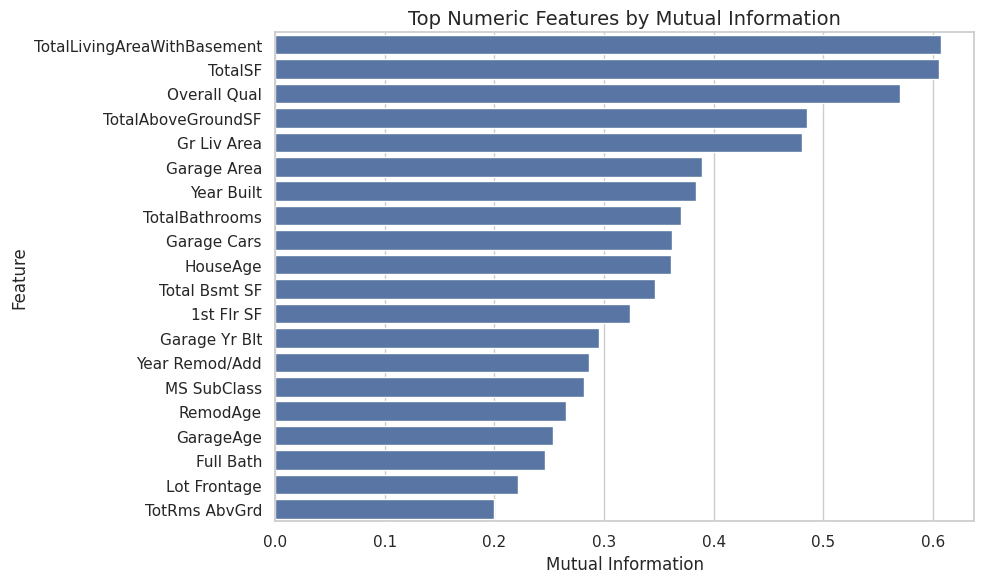

In [78]:
# Mutual information for numeric features only
num_for_mi = X[numeric_features].copy()

# Fill missing numeric values before calculating mutual information
num_imputer = SimpleImputer(strategy="median")
num_for_mi = pd.DataFrame(
    num_imputer.fit_transform(num_for_mi),
    columns=numeric_features
)

# Calculate mutual information scores
mi_scores = mutual_info_regression(
    num_for_mi,
    y,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    "Feature": numeric_features,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False)

display(mi_df.head(20))

# Plot the most informative numeric features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=mi_df.head(20),
    x="Mutual Information",
    y="Feature",
    color="C0"
)

plt.title("Top Numeric Features by Mutual Information")
plt.tight_layout()
plt.show()

,Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.221777,0.221777
1,2,0.088729,0.310507
2,3,0.070149,0.380655
3,4,0.051993,0.432649
4,5,0.046754,0.479403
5,6,0.038058,0.517461
6,7,0.037321,0.554782
7,8,0.028940,0.583722
8,9,0.026373,0.610095
9,10,0.026153,0.636247


PCA components needed for at least 90% variance: 25


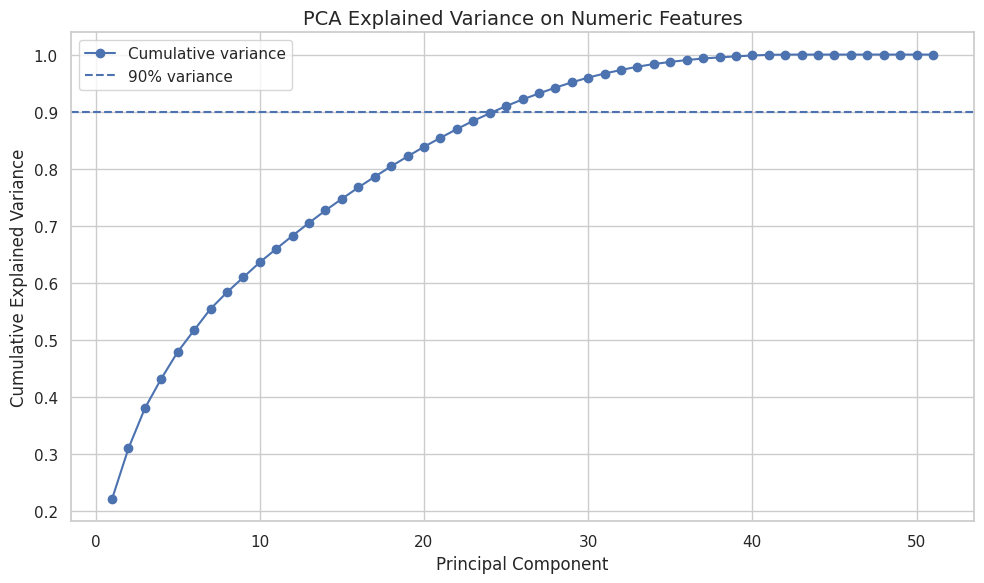

In [79]:
# PCA on numeric features only, used for analysis and not for final prediction
numeric_pca_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Scale numeric features before applying PCA
num_scaled = numeric_pca_pipeline.fit_transform(X[numeric_features])

# Fit PCA
pca = PCA(random_state=RANDOM_STATE)
pca.fit(num_scaled)

# Explained variance by component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(pca_df.head(15))

# Number of components needed to explain at least 90% of the variance
components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
print("PCA components needed for at least 90% variance:", components_90)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(
    pca_df["Component"],
    pca_df["Cumulative Explained Variance"],
    marker="o",
    label="Cumulative variance"
)

plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on Numeric Features")
plt.legend()
plt.tight_layout()
plt.show()

# PART 4 — Advanced Preprocessing, Model Building & Ensemble

This part builds the final prediction pipeline. It keeps the feature engineering explainable, evaluates each model with cross-validation, and then combines the models using an ensemble.

## 4.1 — Enhanced Preprocessing

Train rows: 2344 (no outlier removal)
Target: log1p(SalePrice). Raw mean=$178,582, log mean=12.0118


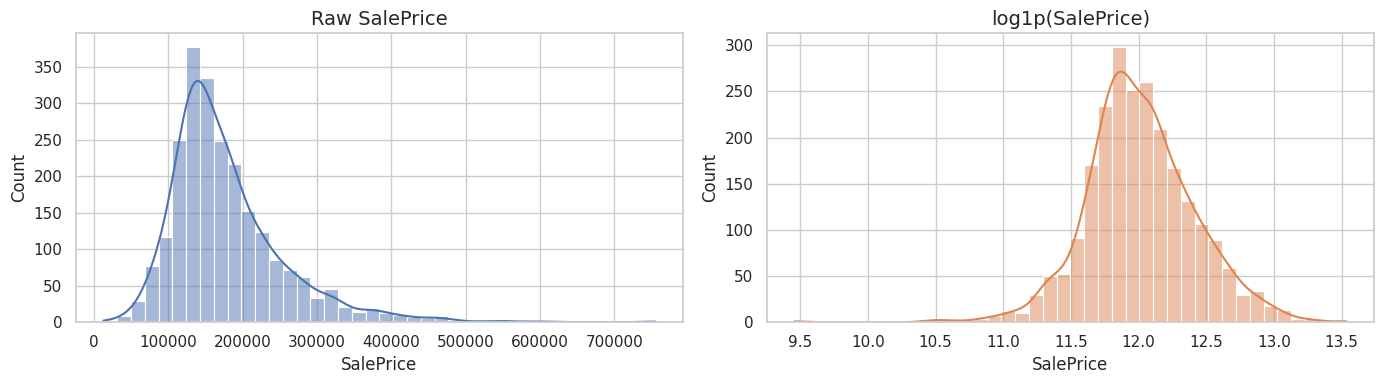

In [80]:
# Keep all rows instead of removing outliers
# Some unusual points may still represent real sale patterns, so they are kept.
train_clean = train.copy()

# Use log1p transformation to make the target distribution less skewed
y_raw = train_clean[TARGET_COL].copy()
y = np.log1p(y_raw)

print(f"Train rows: {len(train_clean)} (no outlier removal)")
print(f"Target: log1p(SalePrice). Raw mean=${y_raw.mean():,.0f}, log mean={y.mean():.4f}")

# Compare the raw and transformed target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y_raw, kde=True, bins=40, ax=axes[0], color="C0")
axes[0].set_title("Raw SalePrice")

sns.histplot(y, kde=True, bins=40, ax=axes[1], color="C1")
axes[1].set_title("log1p(SalePrice)")

plt.tight_layout()
plt.show()

In [81]:
# Ordinal mappings for categorical features with a natural order
# Example: Ex > Gd > TA > Fa > Po
QUALITY_MAP_5 = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "None": 0
}

ORDINAL_COLS_MAP = {
    "Exter Qual": QUALITY_MAP_5,
    "Exter Cond": QUALITY_MAP_5,
    "Bsmt Qual": QUALITY_MAP_5,
    "Bsmt Cond": QUALITY_MAP_5,
    "Heating QC": QUALITY_MAP_5,
    "Kitchen Qual": QUALITY_MAP_5,
    "Fireplace Qu": QUALITY_MAP_5,
    "Garage Qual": QUALITY_MAP_5,
    "Garage Cond": QUALITY_MAP_5,

    "Pool QC": {"Ex": 4, "Gd": 3, "TA": 2, "Fa": 1, "None": 0},
    "Bsmt Exposure": {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0},
    "BsmtFin Type 1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "BsmtFin Type 2": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "Garage Finish": {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0},
    "Fence": {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0},

    "Functional": {"Typ": 8, "Min1": 7, "Min2": 6, "Mod": 5, "Maj1": 4, "Maj2": 3, "Sev": 2, "Sal": 1},
    "Land Slope": {"Gtl": 3, "Mod": 2, "Sev": 1},
    "Lot Shape": {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1},
    "Utilities": {"AllPub": 4, "NoSewr": 3, "NoSeWa": 2, "ELO": 1},
    "Paved Drive": {"Y": 3, "P": 2, "N": 1},
    "Electrical": {"SBrkr": 5, "FuseA": 4, "FuseF": 3, "FuseP": 2, "Mix": 1},
    "Central Air": {"Y": 1, "N": 0},
    "Street": {"Pave": 1, "Grvl": 0},
}

print(f"Defined ordinal mappings for {len(ORDINAL_COLS_MAP)} columns.")

Defined ordinal mappings for 23 columns.


In [82]:
# Neighborhood price map from the training data
nbhd_price_map = train_clean.groupby("Neighborhood")["SalePrice"].median().to_dict()
nbhd_price_fallback = np.median(list(nbhd_price_map.values()))


def preprocess_and_engineer(df):
    """
    Apply preprocessing and feature engineering.
    This includes missing value handling, ordinal encoding,
    and additional house-related features.
    """
    df = df.copy()

    # Fill missing values that represent absence of a feature
    for col in NONE_CATEGORICAL_COLS:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    for col in ZERO_NUMERIC_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Fill selected remaining missing values
    if "Lot Frontage" in df.columns and "Neighborhood" in df.columns:
        df["Lot Frontage"] = df.groupby("Neighborhood")["Lot Frontage"].transform(
            lambda x: x.fillna(x.median())
        )
        df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

    if "Electrical" in df.columns:
        df["Electrical"] = df["Electrical"].fillna("SBrkr")

    if "MS Zoning" in df.columns:
        df["MS Zoning"] = df["MS Zoning"].fillna("RL")

    # Encode ordered categorical columns
    for col, mapping in ORDINAL_COLS_MAP.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)

    # Add neighborhood median price as a feature
    if "Neighborhood" in df.columns:
        df["NbhdPriceMedian"] = df["Neighborhood"].map(nbhd_price_map).fillna(nbhd_price_fallback)
        df["NbhdPriceMedian_log"] = np.log1p(df["NbhdPriceMedian"])

    # Size-related features
    if {"Total Bsmt SF", "1st Flr SF", "2nd Flr SF"}.issubset(df.columns):
        df["TotalSF"] = df["Total Bsmt SF"] + df["1st Flr SF"] + df["2nd Flr SF"]

    if {"1st Flr SF", "2nd Flr SF"}.issubset(df.columns):
        df["TotalAboveGroundSF"] = df["1st Flr SF"] + df["2nd Flr SF"]

    if {"Gr Liv Area", "Total Bsmt SF"}.issubset(df.columns):
        df["TotalLivingAreaWithBasement"] = df["Gr Liv Area"] + df["Total Bsmt SF"]

    # Bathroom feature
    bath_cols = ["Full Bath", "Half Bath", "Bsmt Full Bath", "Bsmt Half Bath"]
    if all(col in df.columns for col in bath_cols):
        df["TotalBathrooms"] = (
            df["Full Bath"] +
            0.5 * df["Half Bath"] +
            df["Bsmt Full Bath"] +
            0.5 * df["Bsmt Half Bath"]
        )

    # Age-related features
    if {"Yr Sold", "Year Built"}.issubset(df.columns):
        df["HouseAge"] = df["Yr Sold"] - df["Year Built"]
        df["IsNewHouse"] = (df["HouseAge"] <= 1).astype(int)

    if {"Yr Sold", "Year Remod/Add", "Year Built"}.issubset(df.columns):
        df["RemodAge"] = df["Yr Sold"] - df["Year Remod/Add"]
        df["WasRemodeled"] = (df["Year Remod/Add"] != df["Year Built"]).astype(int)

    if {"Yr Sold", "Garage Yr Blt"}.issubset(df.columns):
        df["GarageAge"] = df["Yr Sold"] - df["Garage Yr Blt"]
        df.loc[df["Garage Yr Blt"] == 0, "GarageAge"] = 0

    # Porch and outdoor area
    porch_cols = ["Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch", "Wood Deck SF"]
    existing_porch_cols = [col for col in porch_cols if col in df.columns]

    if existing_porch_cols:
        df["TotalPorchSF"] = df[existing_porch_cols].sum(axis=1)

    # Binary indicator features
    binary_features = {
        "HasGarage": "Garage Area",
        "HasBasement": "Total Bsmt SF",
        "HasFireplace": "Fireplaces",
        "HasPool": "Pool Area",
        "Has2ndFloor": "2nd Flr SF",
        "HasMasVnr": "Mas Vnr Area",
        "HasWoodDeck": "Wood Deck SF",
        "HasPorch": "TotalPorchSF"
    }

    for new_col, base_col in binary_features.items():
        if base_col in df.columns:
            df[new_col] = (df[base_col] > 0).astype(int)

    # Sale condition indicators
    if "Sale Condition" in df.columns:
        df["IsPartialSale"] = (df["Sale Condition"] == "Partial").astype(int)
        df["IsAbnormlSale"] = (df["Sale Condition"] == "Abnorml").astype(int)
        df["IsFamilySale"] = (df["Sale Condition"] == "Family").astype(int)

    # Quality and size interaction features
    interaction_features = [
        ("QualLivArea", "Overall Qual", "Gr Liv Area"),
        ("QualTotalSF", "Overall Qual", "TotalSF"),
        ("QualBsmtSF", "Overall Qual", "Total Bsmt SF"),
        ("KitchenQualLivArea", "Kitchen Qual", "Gr Liv Area"),
        ("ExterQualLivArea", "Exter Qual", "Gr Liv Area"),
        ("BsmtQualBsmtSF", "Bsmt Qual", "Total Bsmt SF"),
        ("GarageQualArea", "Garage Qual", "Garage Area"),
        ("QualCondProduct", "Overall Qual", "Overall Cond"),
        ("QualBath", "Overall Qual", "TotalBathrooms"),
        ("QualGarageCars", "Overall Qual", "Garage Cars"),
        ("PartialSaleXLivArea", "IsPartialSale", "Gr Liv Area")
    ]

    for new_col, col1, col2 in interaction_features:
        if col1 in df.columns and col2 in df.columns:
            df[new_col] = df[col1] * df[col2]

    # Ratio features
    ratio_features = [
        ("LivAreaPerRoom", "Gr Liv Area", "TotRms AbvGrd"),
        ("BsmtToFirstFlrRatio", "Total Bsmt SF", "1st Flr SF"),
        ("GarageToLivAreaRatio", "Garage Area", "Gr Liv Area"),
        ("LotToLivAreaRatio", "Lot Area", "Gr Liv Area"),
        ("LivAreaPerBedroom", "Gr Liv Area", "Bedroom AbvGr")
    ]

    for new_col, numerator, denominator in ratio_features:
        if numerator in df.columns and denominator in df.columns:
            df[new_col] = df[numerator] / (df[denominator] + 1)

    # Squared features for selected important numeric variables
    for col in ["Overall Qual", "Gr Liv Area", "TotalSF", "Garage Area", "TotalBathrooms"]:
        if col in df.columns:
            df[f"{col}_sq"] = df[col] ** 2

    # Treat MS SubClass as categorical
    if "MS SubClass" in df.columns:
        df["MS SubClass"] = df["MS SubClass"].astype(str)

    # Simple time feature
    if {"Mo Sold", "Yr Sold"}.issubset(df.columns):
        df["SoldYYMM"] = df["Yr Sold"] * 100 + df["Mo Sold"]

    # Combined categorical features
    if {"Sale Type", "Sale Condition"}.issubset(df.columns):
        df["SaleTypeCond"] = df["Sale Type"] + "_" + df["Sale Condition"]

    if {"Condition 1", "Condition 2"}.issubset(df.columns):
        df["Cond12"] = df["Condition 1"] + "_" + df["Condition 2"]

    if {"Exterior 1st", "Exterior 2nd"}.issubset(df.columns):
        df["Ext12"] = df["Exterior 1st"] + "_" + df["Exterior 2nd"]

    return df


print("Preprocessing and feature engineering function defined.")

Preprocessing and feature engineering function defined.


In [83]:
# Apply preprocessing and feature engineering
train_pp = preprocess_and_engineer(train_clean)
test_pp = preprocess_and_engineer(test)

# Neighborhood-level price statistics from the training data
nbhd_stats = (
    train_clean
    .groupby("Neighborhood")["SalePrice"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

nbhd_stats.columns = [
    "Neighborhood",
    "Nbhd_PriceMean",
    "Nbhd_PriceMedian",
    "Nbhd_PriceStd",
    "Nbhd_Count"
]

# Add neighborhood statistics to train and test
train_pp = train_pp.merge(nbhd_stats, on="Neighborhood", how="left")
test_pp = test_pp.merge(nbhd_stats, on="Neighborhood", how="left")

# Fill possible missing values in test neighborhoods
for col in ["Nbhd_PriceMean", "Nbhd_PriceMedian", "Nbhd_PriceStd", "Nbhd_Count"]:
    train_pp[col] = train_pp[col].fillna(train_pp[col].median())
    test_pp[col] = test_pp[col].fillna(train_pp[col].median())

train_pp["Nbhd_PriceMean_log"] = np.log1p(train_pp["Nbhd_PriceMean"])
test_pp["Nbhd_PriceMean_log"] = np.log1p(test_pp["Nbhd_PriceMean"])

train_pp["Nbhd_PriceMedian_log"] = np.log1p(train_pp["Nbhd_PriceMedian"])
test_pp["Nbhd_PriceMedian_log"] = np.log1p(test_pp["Nbhd_PriceMedian"])

# Prepare feature matrices
X = train_pp.drop(columns=[TARGET_COL] + ID_COLS, errors="ignore")
X_test = test_pp.drop(columns=ID_COLS, errors="ignore")

# Make sure train and test have the same feature columns
X_test = X_test.reindex(columns=X.columns)

# Separate numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Train rows: {len(X)}, Features: {X.shape[1]}")
print(f"Numeric features: {len(numeric_features)}, Categorical features: {len(categorical_features)}")
print(f"Test rows: {len(X_test)}")

new_features = sorted(set(train_pp.columns) - set(train.columns))
print(f"\nNew engineered features ({len(new_features)}):")
print(new_features)

Train rows: 2344, Features: 133
Numeric features: 109, Categorical features: 24
Test rows: 586

New engineered features (54):
['BsmtQualBsmtSF', 'BsmtToFirstFlrRatio', 'Cond12', 'Ext12', 'ExterQualLivArea', 'Garage Area_sq', 'GarageAge', 'GarageQualArea', 'GarageToLivAreaRatio', 'Gr Liv Area_sq', 'Has2ndFloor', 'HasBasement', 'HasFireplace', 'HasGarage', 'HasMasVnr', 'HasPool', 'HasPorch', 'HasWoodDeck', 'HouseAge', 'IsAbnormlSale', 'IsFamilySale', 'IsNewHouse', 'IsPartialSale', 'KitchenQualLivArea', 'LivAreaPerBedroom', 'LivAreaPerRoom', 'LotToLivAreaRatio', 'NbhdPriceMedian', 'NbhdPriceMedian_log', 'Nbhd_Count', 'Nbhd_PriceMean', 'Nbhd_PriceMean_log', 'Nbhd_PriceMedian', 'Nbhd_PriceMedian_log', 'Nbhd_PriceStd', 'Overall Qual_sq', 'PartialSaleXLivArea', 'QualBath', 'QualBsmtSF', 'QualCondProduct', 'QualGarageCars', 'QualLivArea', 'QualTotalSF', 'RemodAge', 'SaleTypeCond', 'SoldYYMM', 'TotalAboveGroundSF', 'TotalBathrooms', 'TotalBathrooms_sq', 'TotalLivingAreaWithBasement', 'TotalPorc

In [84]:
# Two preprocessing versions:
# - ordinal encoding for boosting models
# - one-hot encoding for linear models

# Ordinal encoding for boosting models
X_boost = X.copy()
X_test_boost = X_test.copy()

# Convert categorical columns to strings before encoding
for col in categorical_features:
    X_boost[col] = X_boost[col].astype(str)
    X_test_boost[col] = X_test_boost[col].astype(str)

cat_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit the encoder on both train and test categories
cat_encoder.fit(
    pd.concat(
        [X_boost[categorical_features], X_test_boost[categorical_features]],
        axis=0
    )
)

X_boost[categorical_features] = cat_encoder.transform(X_boost[categorical_features])
X_test_boost[categorical_features] = cat_encoder.transform(X_test_boost[categorical_features])

# Fill any remaining missing values using training medians
for col in X_boost.columns:
    train_median = X_boost[col].median()

    if X_boost[col].isna().any():
        X_boost[col] = X_boost[col].fillna(train_median)

    if X_test_boost[col].isna().any():
        X_test_boost[col] = X_test_boost[col].fillna(train_median)

# One-hot preprocessing pipeline for linear models
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print(f"Boosting feature matrix shape: {X_boost.shape}")
print("Preprocessing pipelines created.")

Boosting feature matrix shape: (2344, 133)
Preprocessing pipelines created.


## 4.2 — Model Definitions and Cross-Validation

In [85]:
def cv_oof_predictions(model, X, y, cv=CV_FOLDS, random_state=RANDOM_STATE):
    """Return out-of-fold predictions and CV RMSE scores."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)

    oof_predictions = np.zeros(len(X))
    scores = []

    for train_idx, val_idx in kf.split(X):
        model_clone = clone(model)

        # Support both pandas DataFrames and numpy arrays
        if hasattr(X, "iloc"):
            X_train_fold = X.iloc[train_idx]
            X_val_fold = X.iloc[val_idx]
        else:
            X_train_fold = X[train_idx]
            X_val_fold = X[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model_clone.fit(X_train_fold, y_train_fold)
        oof_predictions[val_idx] = model_clone.predict(X_val_fold)

        rmse = np.sqrt(mean_squared_error(y_val_fold, oof_predictions[val_idx]))
        scores.append(rmse)

    return oof_predictions, np.array(scores)


# Boosting models using ordinal-encoded features
boost_models = {
    "GBR": GradientBoostingRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        max_features="sqrt",
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=5,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=2000,
        learning_rate=0.02,
        depth=5,
        l2_leaf_reg=3,
        random_seed=RANDOM_STATE,
        verbose=0
    )
}


# Linear models using one-hot encoded features
linear_models = {
    "Ridge": Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=10))
    ]),

    "Lasso": Pipeline([
        ("prep", preprocessor),
        ("model", Lasso(alpha=0.0005, max_iter=10000))
    ])
}

print(f"Defined {len(boost_models)} boosting models and {len(linear_models)} linear models.")

Defined 4 boosting models and 2 linear models.


In [86]:
def evaluate_model_group(models, X_data, y, group_name):
    """Train models with CV and store their OOF predictions and scores."""
    for name, model in models.items():
        print(f"\nTraining {name} ({group_name})...")

        oof, scores = cv_oof_predictions(model, X_data, y, cv=CV_FOLDS)

        oof_preds[name] = oof
        cv_scores[name] = scores

        mean_rmse = scores.mean()
        std_rmse = scores.std()
        dollar_rmse = np.sqrt(mean_squared_error(y_raw, np.expm1(oof)))

        print(
            f"  Log-RMSE: {mean_rmse:.5f} +/- {std_rmse:.5f}"
            f"  |  Dollar RMSE: ${dollar_rmse:,.0f}"
        )


# Train each model and collect out-of-fold predictions
oof_preds = {}
cv_scores = {}

evaluate_model_group(boost_models, X_boost, y, "boosting")
evaluate_model_group(linear_models, X, y, "linear")


# Summary table
summary = pd.DataFrame({
    name: {
        "Log-RMSE mean": scores.mean(),
        "Log-RMSE std": scores.std(),
        "Dollar RMSE": np.sqrt(mean_squared_error(y_raw, np.expm1(oof_preds[name])))
    }
    for name, scores in cv_scores.items()
}).T.sort_values("Log-RMSE mean")

display(summary)


Training GBR (boosting)...
  Log-RMSE: 0.12036 +/- 0.02306  |  Dollar RMSE: $24,095

Training XGBoost (boosting)...
  Log-RMSE: 0.12279 +/- 0.02325  |  Dollar RMSE: $24,525

Training LightGBM (boosting)...
  Log-RMSE: 0.12555 +/- 0.02365  |  Dollar RMSE: $24,655

Training CatBoost (boosting)...
  Log-RMSE: 0.13024 +/- 0.03698  |  Dollar RMSE: $47,268


,Log-RMSE mean,Log-RMSE std,Dollar RMSE
CatBoost,0.119875,0.023361,23101.182634
GBR,0.120358,0.023064,24095.096622
XGBoost,0.122795,0.023251,24524.861989
LightGBM,0.125546,0.023651,24654.805413
Ridge,0.127156,0.029583,34813.865027
Lasso,0.130241,0.036984,47268.050744


## 4.3 — Ensemble

In [87]:
# Use models ordered by validation performance
blend_names = summary.index.tolist()

# Weighted average: better models get slightly higher weights
weights_raw = 1 / summary["Log-RMSE mean"].values
weights = weights_raw / weights_raw.sum()

print("Blend weights:")
for name, weight in zip(blend_names, weights):
    print(f"  {name}: {weight:.4f}")


# Weighted blend of OOF predictions
blend_oof = np.zeros(len(X))

for name, weight in zip(blend_names, weights):
    blend_oof += weight * oof_preds[name]

blend_rmse_log = np.sqrt(mean_squared_error(y, blend_oof))
blend_rmse_dollar = np.sqrt(mean_squared_error(y_raw, np.expm1(blend_oof)))

print(
    f"\nWeighted Blend -- Log-RMSE: {blend_rmse_log:.5f}, "
    f"Dollar RMSE: ${blend_rmse_dollar:,.0f}"
)


# Ridge stacking using OOF predictions
oof_matrix = np.column_stack([oof_preds[name] for name in blend_names])

stacker = Ridge(alpha=0.5)
kf_stack = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

stack_oof = np.zeros(len(X))
stack_scores = []

for train_idx, val_idx in kf_stack.split(oof_matrix):
    stacker_clone = clone(stacker)

    stacker_clone.fit(oof_matrix[train_idx], y.iloc[train_idx])
    stack_oof[val_idx] = stacker_clone.predict(oof_matrix[val_idx])

    rmse = np.sqrt(mean_squared_error(y.iloc[val_idx], stack_oof[val_idx]))
    stack_scores.append(rmse)

stack_rmse_log = np.mean(stack_scores)
stack_rmse_dollar = np.sqrt(mean_squared_error(y_raw, np.expm1(stack_oof)))

print(
    f"\nRidge Stacker -- Log-RMSE: {stack_rmse_log:.5f}, "
    f"Dollar RMSE: ${stack_rmse_dollar:,.0f}"
)


# Select the ensemble with the lower log-RMSE
if stack_rmse_log < blend_rmse_log:
    best_method = "RidgeStacker"
else:
    best_method = "WeightedBlend"

print(f"\nBest ensemble method: {best_method}")

Blend weights:
  CatBoost: 0.1727
  GBR: 0.1720
  XGBoost: 0.1686
  LightGBM: 0.1649
  Ridge: 0.1628
  Lasso: 0.1590

Weighted Blend -- Log-RMSE: 0.12244, Dollar RMSE: $26,144

Ridge Stacker -- Log-RMSE: 0.12055, Dollar RMSE: $26,757

Best ensemble method: RidgeStacker


## 4.4 — Generate Final Test Predictions

In [88]:
def fit_models_and_predict(models, X_train, X_test_data, y, test_preds):
    """Fit each model on the full training data and predict on the test set."""
    for name, model in models.items():
        print(f"Fitting {name} on full training data...")

        model.fit(X_train, y)
        test_preds[name] = model.predict(X_test_data)

        pred_prices = np.expm1(test_preds[name])

        print(
            f"  Predictions range: "
            f"[${pred_prices.min():,.0f}, ${pred_prices.max():,.0f}]"
        )


# Generate predictions from each individual model
test_preds = {}

fit_models_and_predict(boost_models, X_boost, X_test_boost, y, test_preds)
fit_models_and_predict(linear_models, X, X_test, y, test_preds)


# Select final predictions using the best ensemble method
if best_method == "WeightedBlend":
    final_log_preds = sum(
        weight * test_preds[name]
        for weight, name in zip(weights, blend_names)
    )
else:
    stacker.fit(oof_matrix, y)

    test_matrix = np.column_stack([
        test_preds[name]
        for name in blend_names
    ])

    final_log_preds = stacker.predict(test_matrix)


# Convert predictions back to SalePrice scale
final_preds = np.expm1(final_log_preds)
final_preds = np.clip(final_preds, 0, None)

print(f"\nFinal predictions -- Mean: ${final_preds.mean():,.0f}, Median: ${np.median(final_preds):,.0f}")
print(f"Range: [${final_preds.min():,.0f}, ${final_preds.max():,.0f}]")

Fitting GBR on full training data...
  Predictions range: [$36,141, $597,235]
Fitting XGBoost on full training data...
  Predictions range: [$35,097, $581,056]
Fitting LightGBM on full training data...
  Predictions range: [$34,431, $552,114]
Fitting CatBoost on full training data...
  Predictions range: [$36,394, $592,200]
Fitting Ridge on full training data...
  Predictions range: [$42,512, $526,388]
Fitting Lasso on full training data...
  Predictions range: [$45,782, $510,551]

Final predictions -- Mean: $187,462, Median: $166,137
Range: [$35,932, $577,145]


## 4.5 — Create Submission File

In [89]:
# Create the submission file
submission = pd.DataFrame({
    submission_id_col: test[submission_id_col].values,
    "SalePrice": final_preds
})

# Check that the submission has the correct size and ID order
assert len(submission) == len(test), "Row count mismatch."
assert (
    submission[submission_id_col].values == sample_submission[submission_id_col].values
).all(), "Submission IDs do not match the sample submission."

# Save the file
submission.to_csv("submission.csv", index=False)

print("Submission saved as submission.csv")
print("Submission shape:", submission.shape)

display(submission.head(10))

Submission saved as submission.csv
Submission shape: (586, 2)


,PID,SalePrice
0,903427090,158384.871427
1,527450460,106765.247530
2,908128100,187618.292520
3,907135180,124642.562711
4,910200080,117077.740534
5,528221010,178007.902776
6,909455060,148759.187853
7,527453060,147594.548913
8,904100190,98452.086152
9,528118060,361486.994481


# PART 5 — Model Interpretation


Model performance summary:


,Model,CV MSE Mean,CV MSE Std,CV RMSE Mean,CV MAE Mean
0,CatBoost,5.336646e+08,NaN,23101.182634,13222.197461
1,GBR,5.805737e+08,NaN,24095.096622,13187.007494
2,XGBoost,6.014689e+08,NaN,24524.861989,13433.566398
3,LightGBM,6.078594e+08,NaN,24654.805413,13827.154665
4,Ridge Stacker Blend,7.159532e+08,NaN,26757.301370,13010.936992
5,Ridge,1.212005e+09,NaN,34813.865027,13995.484393
6,Lasso,2.234269e+09,NaN,47268.050744,14452.437873


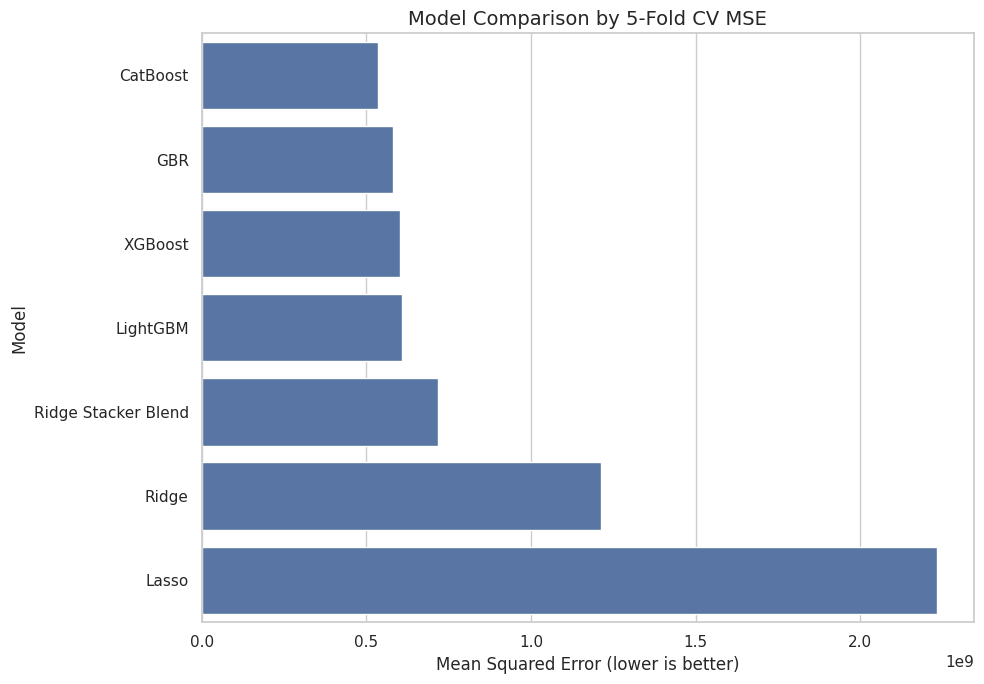

In [91]:
# Build a model performance table using the out-of-fold predictions
performance_rows = []

for model_name, oof_log_preds in oof_preds.items():
    oof_price_preds = np.expm1(oof_log_preds)

    performance_rows.append({
        "Model": model_name,
        "CV MSE Mean": mean_squared_error(y_raw, oof_price_preds),
        "CV MSE Std": np.nan,
        "CV RMSE Mean": np.sqrt(mean_squared_error(y_raw, oof_price_preds)),
        "CV MAE Mean": mean_absolute_error(y_raw, oof_price_preds)
    })

# Add the selected ensemble to the same table
if best_method == "WeightedBlend":
    best_model_name = "Manual Diverse Blend"
    train_pred_log = blend_oof
else:
    best_model_name = "Ridge Stacker Blend"
    train_pred_log = stack_oof

train_pred = np.expm1(train_pred_log)

performance_rows.append({
    "Model": best_model_name,
    "CV MSE Mean": mean_squared_error(y_raw, train_pred),
    "CV MSE Std": np.nan,
    "CV RMSE Mean": np.sqrt(mean_squared_error(y_raw, train_pred)),
    "CV MAE Mean": mean_absolute_error(y_raw, train_pred)
})

all_results_df = (
    pd.DataFrame(performance_rows)
    .sort_values("CV MSE Mean")
    .reset_index(drop=True)
)

# Display table similar to the model comparison output
print("Model performance summary:")
display(all_results_df)

# Plot model comparison
plt.figure(figsize=(10, 7))

sns.barplot(
    data=all_results_df,
    x="CV MSE Mean",
    y="Model",
    color="C0"
)

plt.title("Model Comparison by 5-Fold CV MSE")
plt.xlabel("Mean Squared Error (lower is better)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [93]:
# Final model summary
best_cv_mse = all_results_df.loc[
    all_results_df["Model"] == best_model_name,
    "CV MSE Mean"
].iloc[0]

print("Final selected model:", best_model_name)
print(f"Best cross-validation MSE: {best_cv_mse:,.2f}")
print(f"Best cross-validation RMSE: {np.sqrt(best_cv_mse):,.2f}")

print("Top 10 models by CV MSE:")
display(all_results_df.head(10))

Final selected model: Ridge Stacker Blend
Best cross-validation MSE: 715,953,176.63
Best cross-validation RMSE: 26,757.30
Top 10 models by CV MSE:


,Model,CV MSE Mean,CV MSE Std,CV RMSE Mean,CV MAE Mean
0,CatBoost,5.336646e+08,NaN,23101.182634,13222.197461
1,GBR,5.805737e+08,NaN,24095.096622,13187.007494
2,XGBoost,6.014689e+08,NaN,24524.861989,13433.566398
3,LightGBM,6.078594e+08,NaN,24654.805413,13827.154665
4,Ridge Stacker Blend,7.159532e+08,NaN,26757.301370,13010.936992
5,Ridge,1.212005e+09,NaN,34813.865027,13995.484393
6,Lasso,2.234269e+09,NaN,47268.050744,14452.437873


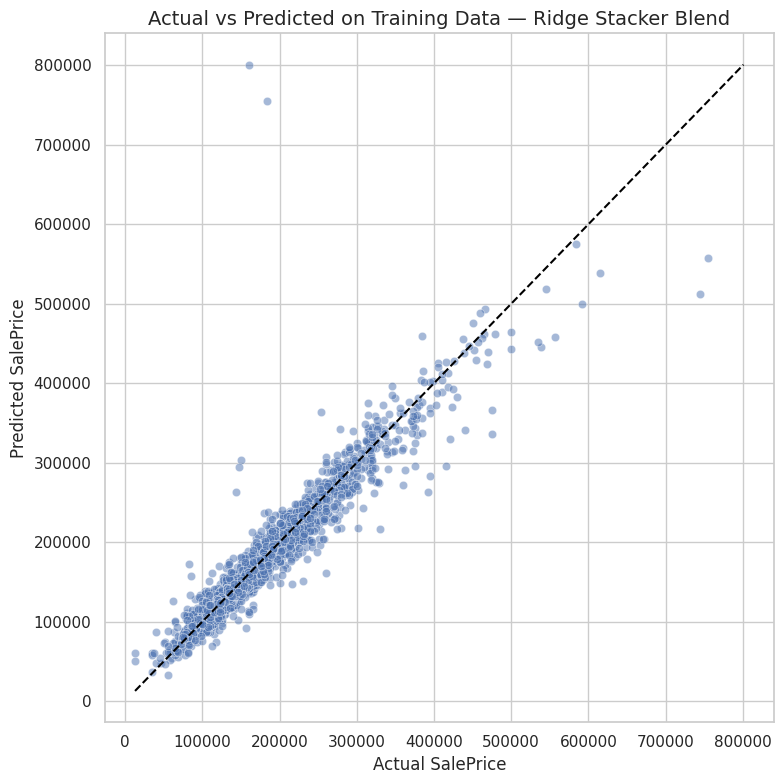

In [94]:
# Actual vs predicted plot on the training data
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_raw,
    y=train_pred,
    alpha=0.5
)

plot_min = min(y_raw.min(), train_pred.min())
plot_max = max(y_raw.max(), train_pred.max())

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "--",
    color="black"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted on Training Data — {best_model_name}")
plt.tight_layout()
plt.show()

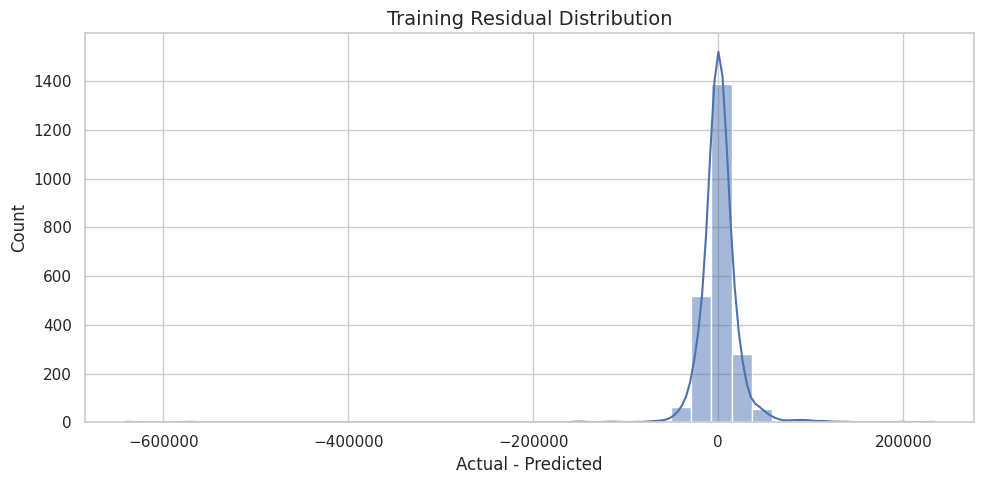

In [95]:
# Residual distribution
residuals = y_raw - train_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color="C0"
)

plt.title("Training Residual Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Count")
plt.tight_layout()
plt.show()